<a href="https://colab.research.google.com/github/markajbell/BH/blob/main/Import.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Download Data

In [20]:
import os
from IPython.display import clear_output
# create a data folder under content and import all the files from the data folder in github (https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/data)
if os.path.exists("/content/data"):
  print("/content/data exists")
else:
  !wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/data/data.zip
  #!wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/data/data.zip
  !wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/data/DU-Phan.json
  !wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/data/sp-tier0.json
  #!wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/data/bh-4.json
  #!wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/data/bh-5-6016-5981.json
  #!wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/data/bh-6-all_tier_0.json
  #!wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/data/tier0.json
  #!mkdir /content/data
  !unzip data.zip -d data
  #!unzip mylab.zip -d mylab

  clear_output()
  print("Downloading lab files...Done")



--2025-05-21 20:32:20--  https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/data/sp-tier0.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48383 (47K) [text/plain]
Saving to: ‘sp-tier0.json.1’

sp-tier0.json.1     100%[===================>]  47.25K  --.-KB/s    in 0.002s  

2025-05-21 20:32:20 (19.2 MB/s) - ‘sp-tier0.json.1’ saved [48383/48383]



# Import JSON

In [3]:
#Install dependencies

!pip install pandas

import pandas as pd
import json

# Open JSON file
with open('data/sp-tier0.json', 'r') as f:
    data_all = json.load(f)

#Create a dataframe from the uploaded JSON

df_all = pd.DataFrame(data_all)

# Display the first few rows of the DataFrame to verify
print(df_all.head())

                                                    data
nodes  {'5177': {'label': 'DE-DAS-DISTLIST1@MYLAB.LOC...
edges  [{'source': '7630', 'target': '5188', 'label':...


In [ ]:
#set the display correctly to view all data
pd.set_option("display.max_colwidth", None)
df_all

In [4]:
# Find the keys from the created df
df_all['data'].keys()

Index(['nodes', 'edges'], dtype='object')

In [5]:
# extract the 'nodes' into a seperate dataframe called nodes_all &
# transform for correct layout. Set the column headers as ID, name,
#kind, group, SID, OID, istier0, isOwned and lastSeen.

import pandas as pd
pd.set_option("display.max_colwidth", None)
nodes_all = pd.DataFrame(df_all['data']['nodes']).T
nodes_all.columns = ['label', 'kind', 'OID', 'istier0', 'isOwned', 'lastSeen']
#print(nodes_all)
#clear_output()

                                     label   kind  \
5177          DE-DAS-DISTLIST1@MYLAB.LOCAL  Group   
5179          RO-ARJ-DISTLIST1@MYLAB.LOCAL  Group   
5188  BR-EDUFER191-ADMINGROUP1@MYLAB.LOCAL  Group   
6889              6372101301SA@MYLAB.LOCAL   User   
7204               DORTHY_ROWE@MYLAB.LOCAL   User   
7583             CLAUDE_GIBSON@MYLAB.LOCAL   User   
7630           ROSEANN_FISCHER@MYLAB.LOCAL   User   
7675            STEWART_THOMAS@MYLAB.LOCAL   User   
9999                     tier0@MYLAB.LOCAL  tier0   

                                                OID istier0 isOwned  \
5177  S-1-5-21-1333368235-828418111-1849936505-3600   False   False   
5179  S-1-5-21-1333368235-828418111-1849936505-3635   False   False   
5188  S-1-5-21-1333368235-828418111-1849936505-3849   False   False   
6889  S-1-5-21-1333368235-828418111-1849936505-2469   False   False   
7204  S-1-5-21-1333368235-828418111-1849936505-2800    True   False   
7583  S-1-5-21-1333368235-828418111-1849936

In [6]:
# convert the keys for nodes_all to an integer
# then create a seperate index on nodes_all starting at 0

nodes_all.index = nodes_all.index.astype(int)
nodes_all = nodes_all.reset_index().rename(columns={'index': 'node_id'})
#nodes_all

,node_id,label,kind,OID,istier0,isOwned,lastSeen
0,5177,DE-DAS-DISTLIST1@MYLAB.LOCAL,Group,S-1-5-21-1333368235-828418111-1849936505-3600,False,False,2025-05-13T13:28:49.122Z
1,5179,RO-ARJ-DISTLIST1@MYLAB.LOCAL,Group,S-1-5-21-1333368235-828418111-1849936505-3635,False,False,2025-05-13T13:28:49.122Z
2,5188,BR-EDUFER191-ADMINGROUP1@MYLAB.LOCAL,Group,S-1-5-21-1333368235-828418111-1849936505-3849,False,False,2025-05-13T13:28:44.994145201Z
3,6889,6372101301SA@MYLAB.LOCAL,User,S-1-5-21-1333368235-828418111-1849936505-2469,False,False,2025-05-13T13:28:48.484Z
4,7204,DORTHY_ROWE@MYLAB.LOCAL,User,S-1-5-21-1333368235-828418111-1849936505-2800,True,False,2025-05-13T13:28:41.852961635Z
5,7583,CLAUDE_GIBSON@MYLAB.LOCAL,User,S-1-5-21-1333368235-828418111-1849936505-3196,False,False,2025-05-13T13:28:48.484Z
6,7630,ROSEANN_FISCHER@MYLAB.LOCAL,User,S-1-5-21-1333368235-828418111-1849936505-3244,False,False,2025-05-13T13:28:48.484Z
7,7675,STEWART_THOMAS@MYLAB.LOCAL,User,S-1-5-21-1333368235-828418111-1849936505-3290,False,False,2025-05-13T13:28:48.484Z
8,9999,tier0@MYLAB.LOCAL,tier0,S-1-5-21-1333368235-828418111-1849936505-9999,True,False,2025-05-13T13:28:48.484Z


In [7]:
# Show type of data in columns
nodes_all.dtypes

,0
node_id,int64
label,object
kind,object
OID,object
istier0,object
isOwned,object
lastSeen,object


In [8]:
# create a seperate dataframe from df_all using the edges key

import pandas as pd
edges_all = pd.DataFrame(df_all['data']['edges'])
#print(edges_all)

In [10]:
# convert edges_all['source') & edges_all['target') to int

edges_all['source'] = edges_all['source'].astype(int)
edges_all['target'] = edges_all['target'].astype(int)

print("\nConverted 'source' column to int:")
print(edges_all['source'].head())
print("\nConverted 'target' column to int:")
print(edges_all['target'].head())

# Verify the data types
print("\nData types after conversion:")
edges_all.dtypes


Converted 'source' column to int:
0    7630
1    5188
2    7583
3    5177
4    5188
Name: source, dtype: int64

Converted 'target' column to int:
0    5188
1    7583
2    5177
3    7204
4    6889
Name: target, dtype: int64

Data types after conversion:


,0
source,int64
target,int64
label,object
kind,object
lastSeen,object


In [11]:
# Show type of data in columns
print(edges_all.columns)
edges_all.dtypes

Index(['source', 'target', 'label', 'kind', 'lastSeen'], dtype='object')


,0
source,int64
target,int64
label,object
kind,object
lastSeen,object


# Apply weighting depending on type of relationships

In [12]:
# Apply the weights based on the 'label' column
def assign_weight(label):
    if label == "GenericAll":
        return 9
    elif label == "Owns":
        return 10
    elif label == "GenericWrite":
        return 2
    elif label == "AllExtendedRights":
        return 6
    elif label == "CanRDP":
        return 2
    elif label == "Contains":
        return 2
    elif label == "DCSync":
        return 8
    elif label == "WriteDacl":
        return 5
    elif label == "WriteOwner":
        return 7
    elif label == "AddKeyCredentialLink":
        return 6
    elif label == "AdminTo":
        return 8
    elif label == "MemberOf":
        return 1
    elif label == "CanPSRemote":
        return 2
    elif label == "ExecuteDCOM":
        return 2
    elif label == "GPLink":
        return 3
    elif label == "tier0":
        return 20
    else:
        return 1 # Default weight for other labels

edges_all['weight'] = edges_all['label'].apply(assign_weight)

# Display the updated edges_all DataFrame with the 'weight' column
print("\nEdges_all DataFrame with weight column:")
edges_all


Edges_all DataFrame with weight column:


,source,target,label,kind,lastSeen,weight
0,7630,5188,MemberOf,MemberOf,2025-05-13T13:28:44.995877259Z,1
1,5188,7583,GenericAll,GenericAll,2025-05-13T13:28:43.548154584Z,9
2,7583,5177,MemberOf,MemberOf,2025-05-13T13:28:44.995877259Z,1
3,5177,7204,GenericAll,GenericAll,2025-05-13T13:28:41.853681099Z,9
4,5188,6889,GenericAll,GenericAll,2025-05-13T13:28:41.684963398Z,9
5,6889,5177,MemberOf,MemberOf,2025-05-13T13:28:44.995877259Z,1
6,5188,7675,GenericAll,GenericAll,2025-05-13T13:28:43.548154584Z,9
7,7675,5179,MemberOf,MemberOf,2025-05-13T13:28:44.995877259Z,1
8,5179,7204,GenericAll,GenericAll,2025-05-13T13:28:41.853681099Z,9
9,7204,9999,tier0,tier0,2025-05-13T13:28:41.853681099Z,20


In [13]:
edges_all.dtypes

,0
source,int64
target,int64
label,object
kind,object
lastSeen,object
weight,int64


In [ ]:
# show all rows

import pandas as pd
pd.set_option('display.max_rows', None)
edges_all

,source,target,label,kind,lastSeen,weight
0,7630,5188,MemberOf,MemberOf,2025-05-13T13:28:44.995877259Z,1
1,5188,7583,GenericAll,GenericAll,2025-05-13T13:28:43.548154584Z,9
2,7583,5177,MemberOf,MemberOf,2025-05-13T13:28:44.995877259Z,1
3,5177,7204,GenericAll,GenericAll,2025-05-13T13:28:41.853681099Z,9
4,5188,6889,GenericAll,GenericAll,2025-05-13T13:28:41.684963398Z,9
5,6889,5177,MemberOf,MemberOf,2025-05-13T13:28:44.995877259Z,1
6,5188,7675,GenericAll,GenericAll,2025-05-13T13:28:43.548154584Z,9
7,7675,5179,MemberOf,MemberOf,2025-05-13T13:28:44.995877259Z,1
8,5179,7204,GenericAll,GenericAll,2025-05-13T13:28:41.853681099Z,9
9,7204,9999,tier0,tier0,2025-05-13T13:28:41.853681099Z,20


In [ ]:
pd.set_option("display.max_colwidth", None)
edges_all

,source,target,label,kind,lastSeen,weight
0,7630,5188,MemberOf,MemberOf,2025-05-13T13:28:44.995877259Z,1
1,5188,7583,GenericAll,GenericAll,2025-05-13T13:28:43.548154584Z,9
2,7583,5177,MemberOf,MemberOf,2025-05-13T13:28:44.995877259Z,1
3,5177,7204,GenericAll,GenericAll,2025-05-13T13:28:41.853681099Z,9
4,5188,6889,GenericAll,GenericAll,2025-05-13T13:28:41.684963398Z,9
5,6889,5177,MemberOf,MemberOf,2025-05-13T13:28:44.995877259Z,1
6,5188,7675,GenericAll,GenericAll,2025-05-13T13:28:43.548154584Z,9
7,7675,5179,MemberOf,MemberOf,2025-05-13T13:28:44.995877259Z,1
8,5179,7204,GenericAll,GenericAll,2025-05-13T13:28:41.853681099Z,9
9,7204,9999,tier0,tier0,2025-05-13T13:28:41.853681099Z,20


In [15]:
# prompt: what the max instance of a single number appearing in edges_all and what is that value. Exclude the value 9999

import pandas as pd
# Flatten the 'source' and 'target' columns into a single list
all_nodes_in_edges = pd.concat([edges_all['source'], edges_all['target']])

# Filter out the value 9999
filtered_nodes = all_nodes_in_edges[all_nodes_in_edges != 9999]

# Get the value counts for each number
value_counts = filtered_nodes.value_counts()

# Find the value with the maximum count
max_instance_value = value_counts.idxmax()
max_instance_count = value_counts.max()

print(f"The value with the maximum instance (excluding 9999) is: {max_instance_value}")
print(f"This value appears {max_instance_count} times in the 'source' and 'target' columns.")

The value with the maximum number of instances is: 5188
It appears 4 times.


# Node

In [ ]:
 # node_6071 = nodes_all[nodes_all['node_id'] == 6071]

import pandas as pd
pd.set_option('display.max_rows', None)
print(nodes_all)
pd.reset_option('display.max_rows') # Reset to default after displaying

   node_id                                 label   kind  \
0     5177          DE-DAS-DISTLIST1@MYLAB.LOCAL  Group   
1     5179          RO-ARJ-DISTLIST1@MYLAB.LOCAL  Group   
2     5188  BR-EDUFER191-ADMINGROUP1@MYLAB.LOCAL  Group   
3     6889              6372101301SA@MYLAB.LOCAL   User   
4     7204               DORTHY_ROWE@MYLAB.LOCAL   User   
5     7583             CLAUDE_GIBSON@MYLAB.LOCAL   User   
6     7630           ROSEANN_FISCHER@MYLAB.LOCAL   User   
7     7675            STEWART_THOMAS@MYLAB.LOCAL   User   
8     9999                     tier0@MYLAB.LOCAL  tier0   

                                             OID istier0 isOwned  \
0  S-1-5-21-1333368235-828418111-1849936505-3600   False   False   
1  S-1-5-21-1333368235-828418111-1849936505-3635   False   False   
2  S-1-5-21-1333368235-828418111-1849936505-3849   False   False   
3  S-1-5-21-1333368235-828418111-1849936505-2469   False   False   
4  S-1-5-21-1333368235-828418111-1849936505-2800    True   False   
5

In [ ]:
pd.set_option("display.max_colwidth", None)
nodes_all


,node_id,label,kind,OID,istier0,isOwned,lastSeen
0,5177,DE-DAS-DISTLIST1@MYLAB.LOCAL,Group,S-1-5-21-1333368235-828418111-1849936505-3600,False,False,2025-05-13T13:28:49.122Z
1,5179,RO-ARJ-DISTLIST1@MYLAB.LOCAL,Group,S-1-5-21-1333368235-828418111-1849936505-3635,False,False,2025-05-13T13:28:49.122Z
2,5188,BR-EDUFER191-ADMINGROUP1@MYLAB.LOCAL,Group,S-1-5-21-1333368235-828418111-1849936505-3849,False,False,2025-05-13T13:28:44.994145201Z
3,6889,6372101301SA@MYLAB.LOCAL,User,S-1-5-21-1333368235-828418111-1849936505-2469,False,False,2025-05-13T13:28:48.484Z
4,7204,DORTHY_ROWE@MYLAB.LOCAL,User,S-1-5-21-1333368235-828418111-1849936505-2800,True,False,2025-05-13T13:28:41.852961635Z
5,7583,CLAUDE_GIBSON@MYLAB.LOCAL,User,S-1-5-21-1333368235-828418111-1849936505-3196,False,False,2025-05-13T13:28:48.484Z
6,7630,ROSEANN_FISCHER@MYLAB.LOCAL,User,S-1-5-21-1333368235-828418111-1849936505-3244,False,False,2025-05-13T13:28:48.484Z
7,7675,STEWART_THOMAS@MYLAB.LOCAL,User,S-1-5-21-1333368235-828418111-1849936505-3290,False,False,2025-05-13T13:28:48.484Z
8,9999,tier0@MYLAB.LOCAL,tier0,S-1-5-21-1333368235-828418111-1849936505-9999,True,False,2025-05-13T13:28:48.484Z


# Import Data for Tier0

In [40]:
# import bh.json and load into a pandas dataframe df

!pip install pandas

import pandas as pd
import json

#load JSON into pd.df
with open('data/sp-tier0.json', 'r') as f:
    tier0 = json.load(f)

df_tier0 = pd.DataFrame(tier0)

# Display the first few rows of the DataFrame to verify
print(df_tier0.head())

In [41]:
# from df_all['data'].keys() extract the 'nodes' into a seperate dataframe called nodes_all. i want the vlues as rows and the column headers as ID, name, kind, group, SID, OID, istier0, isOwned, lastSeen.

import pandas as pd
pd.set_option("display.max_colwidth", None)
nodes_tier0 = pd.DataFrame(df_tier0['data']['nodes']).T
nodes_tier0.columns = ['label', 'kind', 'OID', 'istier0', 'isOwned', 'lastSeen']
#print(nodes_tier0)




In [42]:
nodes_tier0.tail()

,label,kind,OID,istier0,isOwned,lastSeen
1017,SVC_DOMAINJOIN@PHANTOM.CORP,User,S-1-5-21-2697957641-2271029196-387917394-2181,False,False,2025-05-21T13:35:36.865Z
1019,SVC_SHS@PHANTOM.CORP,User,S-1-5-21-2697957641-2271029196-387917394-2165,False,False,2025-05-21T13:35:36.865Z
1021,DAVID@PHANTOM.CORP,User,S-1-5-21-2697957641-2271029196-387917394-2134,False,False,2025-05-21T13:35:36.865Z
1022,SCOTT@PHANTOM.CORP,User,S-1-5-21-2697957641-2271029196-387917394-2143,False,False,2025-05-21T13:35:36.865Z
1023,SVC_PAYADMIN@PHANTOM.CORP,User,S-1-5-21-2697957641-2271029196-387917394-2117,False,False,2025-05-21T13:35:36.865Z


In [55]:
#nodes_tier0.index = nodes_all.index.astype(int)
nodes_tier0 = nodes_tier0.reset_index().rename(columns={'index': 'node_id'})
pd.set_option("display.max_colwidth", None)
pd.set_option('display.max_rows', None)
nodes_tier0

,node_id,label,kind,OID,istier0,isOwned,lastSeen
0,209,USERS@GHOST.CORP,Container,EA1ABAEF-5DC2-4426-B744-21A84A759B5B,True,False,2025-05-21T13:35:31.589Z
1,242,USERS@WRAITH.CORP,Container,2A2FEF21-A610-4A28-AAE0-D5D69A8E5BA8,False,False,2025-05-21T13:35:31.589Z
2,975,ADMINISTRATOR@PHANTOM.CORP,User,S-1-5-21-2697957641-2271029196-387917394-500,True,False,2025-05-21T13:35:36.865Z
3,977,ALICE@PHANTOM.CORP,User,S-1-5-21-2697957641-2271029196-387917394-2173,True,False,2025-05-21T13:35:36.865Z
4,980,BOB@PHANTOM.CORP,User,S-1-5-21-2697957641-2271029196-387917394-2175,True,False,2025-05-21T13:35:38.015Z
5,986,JD@PHANTOM.CORP,User,S-1-5-21-2697957641-2271029196-387917394-2113,True,False,2025-05-21T13:35:37.152Z
6,1194,DOMAIN CONTROLLERS@PHANTOM.CORP,Group,S-1-5-21-2697957641-2271029196-387917394-516,True,False,2025-05-21T13:35:33.837Z
7,1195,SCHEMA ADMINS@PHANTOM.CORP,Group,S-1-5-21-2697957641-2271029196-387917394-518,True,False,2025-05-21T13:35:33.934Z
8,1196,ENTERPRISE ADMINS@PHANTOM.CORP,Group,S-1-5-21-2697957641-2271029196-387917394-519,True,False,2025-05-21T13:35:37.895Z
9,1199,DOMAIN USERS@PHANTOM.CORP,Group,S-1-5-21-2697957641-2271029196-387917394-513,False,False,2025-05-21T13:35:36.081Z


In [44]:
nodes_tier0['node_id'] = nodes_tier0['node_id'].astype(int)

In [45]:
nodes_tier0.dtypes

,0
node_id,int64
label,object
kind,object
OID,object
istier0,object
isOwned,object
lastSeen,object


In [ ]:
# generate a list of node_id from nodes_tier0

nodes_tier0_list=nodes_tier0['node_id'].tolist()
nodes_tier0_list
#

In [46]:
# create a seperate dataframe from df_all using the edges key

import pandas as pd
edges_tier0 = pd.DataFrame(df_tier0['data']['edges'])
#print(edges_all)

In [47]:
edges_tier0

,source,target,label,kind,lastSeen
0,1199,1456,AdminTo,AdminTo,2025-05-21T13:35:52.180600782Z
1,1456,1461,AllowedToDelegate,AllowedToDelegate,2025-05-21T13:35:15.51961565Z
2,1461,1194,MemberOf,MemberOf,2025-05-21T13:35:15.51961565Z
3,1199,1463,AdminTo,AdminTo,2025-05-21T13:35:52.180600782Z
4,1463,975,HasSession,HasSession,2025-05-21T13:35:15.51961565Z
...,...,...,...,...,...
88,1001,1199,MemberOf,MemberOf,2025-05-21T13:35:15.637044368Z
89,1021,1199,MemberOf,MemberOf,2025-05-21T13:35:15.637044368Z
90,1022,1199,MemberOf,MemberOf,2025-05-21T13:35:15.637044368Z
91,1023,1199,MemberOf,MemberOf,2025-05-21T13:35:15.637044368Z


In [48]:
edges_tier0['source'] = edges_tier0['source'].astype(int)
edges_tier0['target'] = edges_tier0['target'].astype(int)
edges_tier0['label'] = edges_tier0['label'].astype(str)

In [ ]:
# if source from edges_all does not contain nodes_tier0_list, then append a new record with the node_tier0_list value and
# target = 9999, label = "tier0", kind= "tier0", lastSeen = "2025-05-19T18:00:00.000Z" and weight = 0 to edges_all

import pandas as pd
# Iterate through each node_id in nodes_tier0_list
for tier0_node in nodes_tier0_list:
    # Check if this tier0_node exists in the 'source' column of edges_all
    if tier0_node not in edges_all['source'].values:
        # If not found, create a new record
        new_record = {
            "source": tier0_node,
            "target": 9999,
            "label": "tier0",
            "kind": "tier0",
            "lastSeen": "2025-05-19T18:00:00.000Z",
            "weight": 0  # Add the weight column with value 0
        }
        # Append the new record to the edges_all DataFrame
        # Use pd.concat for appending a single row or a DataFrame of new rows
        edges_all = pd.concat([edges_all, pd.DataFrame([new_record])], ignore_index=True)

# Display the updated edges_all DataFrame
print("\nEdges_all DataFrame after adding missing tier0 source nodes:")
edges_all

In [35]:
# remove the last record in edges_all

#edges_all = edges_all[:-1]
#print("\nEdges_all DataFrame after removing the last record:")
edges_tier0.dtypes

,0
source,int64
target,int64
label,object
kind,object
lastSeen,object


In [49]:
# prompt: find the source from edges_tier0 with the most occurances and then match that source with the node_id from nodes_tier0 and print out the label

# Count occurrences of each source in edges_tier0
source_counts = edges_tier0['target'].value_counts()

# Find the source with the most occurrences
most_frequent_source = source_counts.idxmax()
most_frequent_count = source_counts.max()

print(f"The source with the most occurrences in edges_tier0 is: {most_frequent_source}")
print(f"It appears {most_frequent_count} times.")

# Match the most frequent source with the node_id in nodes_tier0 and get the label
matched_node = nodes_tier0[nodes_tier0['node_id'] == most_frequent_source]

if not matched_node.empty:
    label_of_most_frequent_source = matched_node['label'].iloc[0]
    print(f"The label for the node_id {most_frequent_source} is: {label_of_most_frequent_source}")
else:
    print(f"Could not find node_id {most_frequent_source} in nodes_tier0.")


The source with the most occurrences in edges_tier0 is: 1199
It appears 44 times.
The label for the node_id 1199 is: DOMAIN USERS@PHANTOM.CORP


# Dijkstra analysis

In [61]:
# prompt: using dijkstra find the shortest path where the (edges_tier0[target] = node_tier0[node_id] and node_tier0[istier0]=true)

import pandas as pd
import heapq

def dijkstra_shortest_path(edges, nodes, start_node_id):
    """
    Finds the shortest paths from a start node to all other nodes
    with a target node that matches a tier0 node and the node is istier0=True,
    using Dijkstra's algorithm.

    Args:
        edges (pd.DataFrame): DataFrame with 'source', 'target', and 'weight' columns.
        nodes (pd.DataFrame): DataFrame with 'node_id' and 'istier0' columns.
        start_node_id (int): The ID of the starting node.

    Returns:
        dict: A dictionary where keys are the node IDs of tier0 nodes
              reachable from the start node, and values are their shortest distances.
        dict: A dictionary to reconstruct the shortest paths.
    """
    # Build the graph as an adjacency list
    graph = {}
    for index, row in edges.iterrows():
        source = row['source']
        target = row['target']
        weight = row['weight']
        if source not in graph:
            graph[source] = []
        graph[source].append((target, weight))

    # Initialize distances and predecessors
    distances = {node_id: float('infinity') for node_id in nodes['node_id'].tolist() + edges['source'].tolist() + edges['target'].tolist()}
    distances[start_node_id] = 0
    predecessors = {node_id: None for node_id in nodes['node_id'].tolist() + edges['source'].tolist() + edges['target'].tolist()}

    # Priority queue for Dijkstra
    priority_queue = [(0, start_node_id)]

    # Filter target nodes based on the criteria (target is a tier0 node and that node is istier0=True)
    tier0_target_nodes = nodes_tier0[(nodes_tier0['istier0'] == True) & (nodes_tier0['node_id'].isin(edges['target'].tolist()))]['node_id'].tolist()

    shortest_paths_to_tier0 = {}

    while priority_queue:
        current_distance, current_node = heapq.heappop(priority_queue)

        # If the current distance is greater than the known distance, skip
        if current_distance > distances[current_node]:
            continue

        # If the current node is a target node matching the criteria, store its distance
        if current_node in tier0_target_nodes:
            shortest_paths_to_tier0[current_node] = current_distance

        # Explore neighbors
        if current_node in graph:
            for neighbor, weight in graph[current_node]:
                distance = current_distance + weight

                # If a shorter path is found
                if distance < distances[neighbor]:
                    distances[neighbor] = distance
                    predecessors[neighbor] = current_node
                    heapq.heappush(priority_queue, (distance, neighbor))

    # Filter the results to only include the tier0 target nodes
    filtered_shortest_paths = {node_id: dist for node_id, dist in distances.items() if node_id in tier0_target_nodes and dist != float('infinity')}
    filtered_predecessors = {node_id: pred for node_id, pred in predecessors.items() if node_id in tier0_target_nodes and pred is not None}

    return filtered_shortest_paths, filtered_predecessors

# Example usage: Find the shortest path from node 6071 to the specified tier0 nodes
start_node = 6071
shortest_paths_to_tier0_targets, path_predecessors = dijkstra_shortest_path(edges_all, nodes_tier0, start_node)

print(f"\nShortest paths from node {start_node} to tier0 target nodes (where the node is istier0=True):")
if shortest_paths_to_tier0_targets:
    for target_node_id, distance in shortest_paths_to_tier0_targets.items():
        # Reconstruct the path
        path = []
        current = target_node_id
        while current is not None:
            path.append(current)
            current = path_predecessors.get(current)
        path.reverse()
        print(f"  To node {target_node_id}: Distance = {distance}, Path = {path}")
else:
    print(f"  No reachable tier0 target nodes (where istier0=True) found from node {start_node}.")



Shortest paths from node 6071 to tier0 target nodes (where the node is istier0=True):
  No reachable tier0 target nodes (where istier0=True) found from node 6071.


In [79]:
# prompt: get a list of nodes from nodes_tier0 where nodes_tier0['istier0']=True and put them in a list called Nodes_tier0_istier0

nodes_tier0_istier0 = nodes_tier0[nodes_tier0['istier0'] == True]['node_id'].tolist()
print("\nList of node IDs from nodes_tier0 where 'istier0' is True:")
nodes_tier0_istier0 = pd.DataFrame(nodes_tier0_istier0 )
nodes_tier0_istier0


List of node IDs from nodes_tier0 where 'istier0' is True:


,0
0,209
1,975
2,977
3,980
4,986
5,1194
6,1195
7,1196
8,1202
9,1216


In [80]:
# prompt: change the columns name in nodes_tier0_istier0  to node_id

nodes_tier0_istier0 = nodes_tier0_istier0.rename(columns={0: 'node_id'})
print("\nDataFrame with 'node_id' column:")
nodes_tier0_istier0


DataFrame with 'node_id' column:


,node_id
0,209
1,975
2,977
3,980
4,986
5,1194
6,1195
7,1196
8,1202
9,1216


In [81]:
# prompt: from edges_tier0 find unique instances of edge_tier0['target'] that match the following:
# edge_tier0['target'] = nodes_tier0_istier0['node_id']

# Find unique instances of edges_tier0['target'] that are also in nodes_tier0_istier0['node_id']
unique_matching_targets = edges_tier0[edges_tier0['target'].isin(nodes_tier0_istier0['node_id'])]['target'].unique()

print("\nUnique instances of edges_tier0['target'] matching nodes_tier0_istier0['node_id']:")
unique_matching_targets


Unique instances of edges_tier0['target'] matching nodes_tier0_istier0['node_id']:


array([1461, 1194,  975, 1195, 1196, 1202,  980, 1216, 1221,  977, 1232,
       1239, 1248, 1261, 1271, 1478, 1479,  209, 1275, 1276, 1279, 1314,
       1316,  986, 1367, 1343, 1344, 1345, 1349, 1350, 1481, 1352, 1354,
       1355, 1368, 1395, 1473, 1405])

In [85]:
# prompt: do any edge_tier0['source'] match values in unique_matching_targets

# Convert unique_matching_targets to a set for efficient lookup
unique_targets_set = set(unique_matching_targets)

# Check if any 'source' value in edges_tier0 is present in unique_targets_set
matches = edges_tier0['source'].isin(unique_targets_set)

# Count the number of matches
num_matches = matches.sum()

if num_matches > 0:
    print(f"\nYes, {num_matches} values in edges_tier0['source'] match values in unique_matching_targets.")
    # Optionally, display the matching source values
    matching_sources = edges_tier0.loc[matches, 'source'].unique()
    matching_sources = pd.DataFrame(matching_sources)
    matching_sources = matching_sources.rename(columns={0: 'node_id'})
    print("Matching source values:", matching_sources)
else:
    print("\nNo values in edges_tier0['source'] match values in unique_matching_targets.")


Yes, 39 values in edges_tier0['source'] match values in unique_matching_targets.
Matching source values:     node_id
0      1461
1       975
2       980
3       977
4      1239
5      1221
6      1478
7      1479
8       209
9      1196
10      986
11     1367
12     1481
13     1473


In [89]:
edges_tier0

,source,target,label,kind,lastSeen,weight
0,1199,1456,AdminTo,AdminTo,2025-05-21T13:35:52.180600782Z,8
1,1456,1461,AllowedToDelegate,AllowedToDelegate,2025-05-21T13:35:15.51961565Z,1
2,1461,1194,MemberOf,MemberOf,2025-05-21T13:35:15.51961565Z,1
3,1199,1463,AdminTo,AdminTo,2025-05-21T13:35:52.180600782Z,8
4,1463,975,HasSession,HasSession,2025-05-21T13:35:15.51961565Z,1
5,975,1195,MemberOf,MemberOf,2025-05-21T13:35:15.600287567Z,1
6,975,1196,MemberOf,MemberOf,2025-05-21T13:35:15.600287567Z,1
7,975,1202,MemberOf,MemberOf,2025-05-21T13:35:15.600287567Z,1
8,1199,1455,AdminTo,AdminTo,2025-05-21T13:35:52.180600782Z,8
9,1455,980,HasSession,HasSession,2025-05-21T13:35:15.51961565Z,1


In [90]:
# prompt:  find the shortest path from edges_tier0['source'] to matching_sources but not where edges_tier0['source] == matching_source['node_id']

import pandas as pd
def dijkstra_shortest_path_excluding_self_target(edges, nodes, start_node_id, target_node_ids_df):
    """
    Finds the shortest paths from a start node to a set of target nodes,
    excluding paths where the source of an edge is the same as the target node ID.

    Args:
        edges (pd.DataFrame): DataFrame with 'source', 'target', and 'weight' columns.
        nodes (pd.DataFrame): DataFrame with 'node_id' column.
        start_node_id (int): The ID of the starting node.
        target_node_ids_df (pd.DataFrame): DataFrame with 'node_id' column
                                           representing the target node IDs.

    Returns:
        dict: A dictionary where keys are the target node IDs reachable from the
              start node, and values are their shortest distances.
        dict: A dictionary to reconstruct the shortest paths.
    """
    # Build the graph as an adjacency list, excluding edges where source == target
    graph = {}
    for index, row in edges.iterrows():
        source = row['source']
        target = row['target']
        weight = row['weight']
        # Exclude edges where source is the same as the target node ID
        if source != target:
            if source not in graph:
                graph[source] = []
            graph[source].append((target, weight))

    # Initialize distances and predecessors
    all_nodes_in_graph = set(nodes['node_id'].tolist())
    all_nodes_in_graph.update(edges['source'].tolist())
    all_nodes_in_graph.update(edges['target'].tolist())

    distances = {node_id: float('infinity') for node_id in all_nodes_in_graph}
    distances[start_node_id] = 0
    predecessors = {node_id: None for node_id in all_nodes_in_graph}

    # Priority queue for Dijkstra
    priority_queue = [(0, start_node_id)]

    # Convert the target node IDs DataFrame to a set for efficient lookup
    target_nodes_set = set(target_node_ids_df['node_id'].tolist())

    shortest_paths_to_targets = {}

    while priority_queue:
        current_distance, current_node = heapq.heappop(priority_queue)

        # If the current distance is greater than the known distance, skip
        if current_distance > distances[current_node]:
            continue

        # If the current node is one of the target nodes, store its distance
        if current_node in target_nodes_set:
            shortest_paths_to_targets[current_node] = current_distance

        # Explore neighbors
        if current_node in graph:
            for neighbor, weight in graph[current_node]:
                distance = current_distance + weight

                # If a shorter path is found
                if distance < distances[neighbor]:
                    distances[neighbor] = distance
                    predecessors[neighbor] = current_node
                    heapq.heappush(priority_queue, (distance, neighbor))

    # Filter the results to only include the reachable target nodes
    filtered_shortest_paths = {node_id: dist for node_id, dist in shortest_paths_to_targets.items() if dist != float('infinity')}
    # Predecessors for reachable target nodes
    filtered_predecessors = {node_id: predecessors[node_id] for node_id in filtered_shortest_paths.keys()}

    return filtered_shortest_paths, filtered_predecessors

# Find the shortest path from edges_tier0['source'] to matching_sources
# but only for sources that are NOT in matching_sources['node_id']

# Get the list of sources from edges_tier0 that are NOT in matching_sources
start_nodes_to_check = edges_tier0[edges_tier0['source'].isin(matching_sources['node_id'])]['source'].unique().tolist()

all_shortest_paths = {}
all_path_predecessors = {}

print("\nFinding shortest paths from sources (not matching target node IDs) to matching_sources:")

if start_nodes_to_check:
    for start_node in start_nodes_to_check:
        print(f"\nChecking shortest paths from start node: {start_node}")
        shortest_paths_from_start, path_predecessors_from_start = dijkstra_shortest_path_excluding_self_target(
            edges_tier0, nodes_tier0, start_node, matching_sources
        )
        all_shortest_paths[start_node] = shortest_paths_from_start
        all_path_predecessors[start_node] = path_predecessors_from_start

        if shortest_paths_from_start:
            for target_node_id, distance in shortest_paths_from_start.items():
                # Reconstruct the path
                path = []
                current = target_node_id
                # Need to handle cases where a target node is reached directly from the start node
                # and the start node is not in the predecessors dict for that path.
                # Check if the target node is in the predecessors dictionary for the current start node's paths.
                while current is not None and current in path_predecessors_from_start:
                     path.append(current)
                     current = path_predecessors_from_start.get(current)
                # If the start node is the immediate predecessor but not in the predecessors dict chain, add it.
                if current == start_node and start_node not in path:
                     path.append(start_node)
                elif current is not None and current not in path and current == start_node:
                     path.append(current)

                path.reverse()

                # Add the start node at the beginning if it's not already there (for direct connections)
                if path and path[0] != start_node:
                    path.insert(0, start_node)


                print(f"  To node {target_node_id}: Distance = {distance}, Path = {path}")
        else:
            print(f"  No reachable target nodes found from node {start_node} (excluding self-targets).")
else:
    print("No start nodes found in edges_tier0 that are not also in matching_sources.")




Finding shortest paths from sources (not matching target node IDs) to matching_sources:

Checking shortest paths from start node: 1461
  To node 1461: Distance = 0, Path = [1461]

Checking shortest paths from start node: 975
  To node 975: Distance = 0, Path = [975]
  To node 1196: Distance = 1, Path = [975, 1196]
  To node 1221: Distance = 1, Path = [975, 1221]
  To node 1239: Distance = 1, Path = [975, 1239]
  To node 1478: Distance = 2, Path = [975, 1478]
  To node 1479: Distance = 3, Path = [975, 1478, 1479]
  To node 1481: Distance = 3, Path = [975, 1478, 1481]
  To node 209: Distance = 5, Path = [975, 1478, 1479, 209]
  To node 977: Distance = 10, Path = [975, 977]
  To node 980: Distance = 10, Path = [975, 980]
  To node 986: Distance = 10, Path = [975, 986]
  To node 1461: Distance = 10, Path = [975, 1461]
  To node 1367: Distance = 11, Path = [975, 986, 1367]
  To node 1473: Distance = 18, Path = [975, 986, 1473]

Checking shortest paths from start node: 980
  To node 980: Di

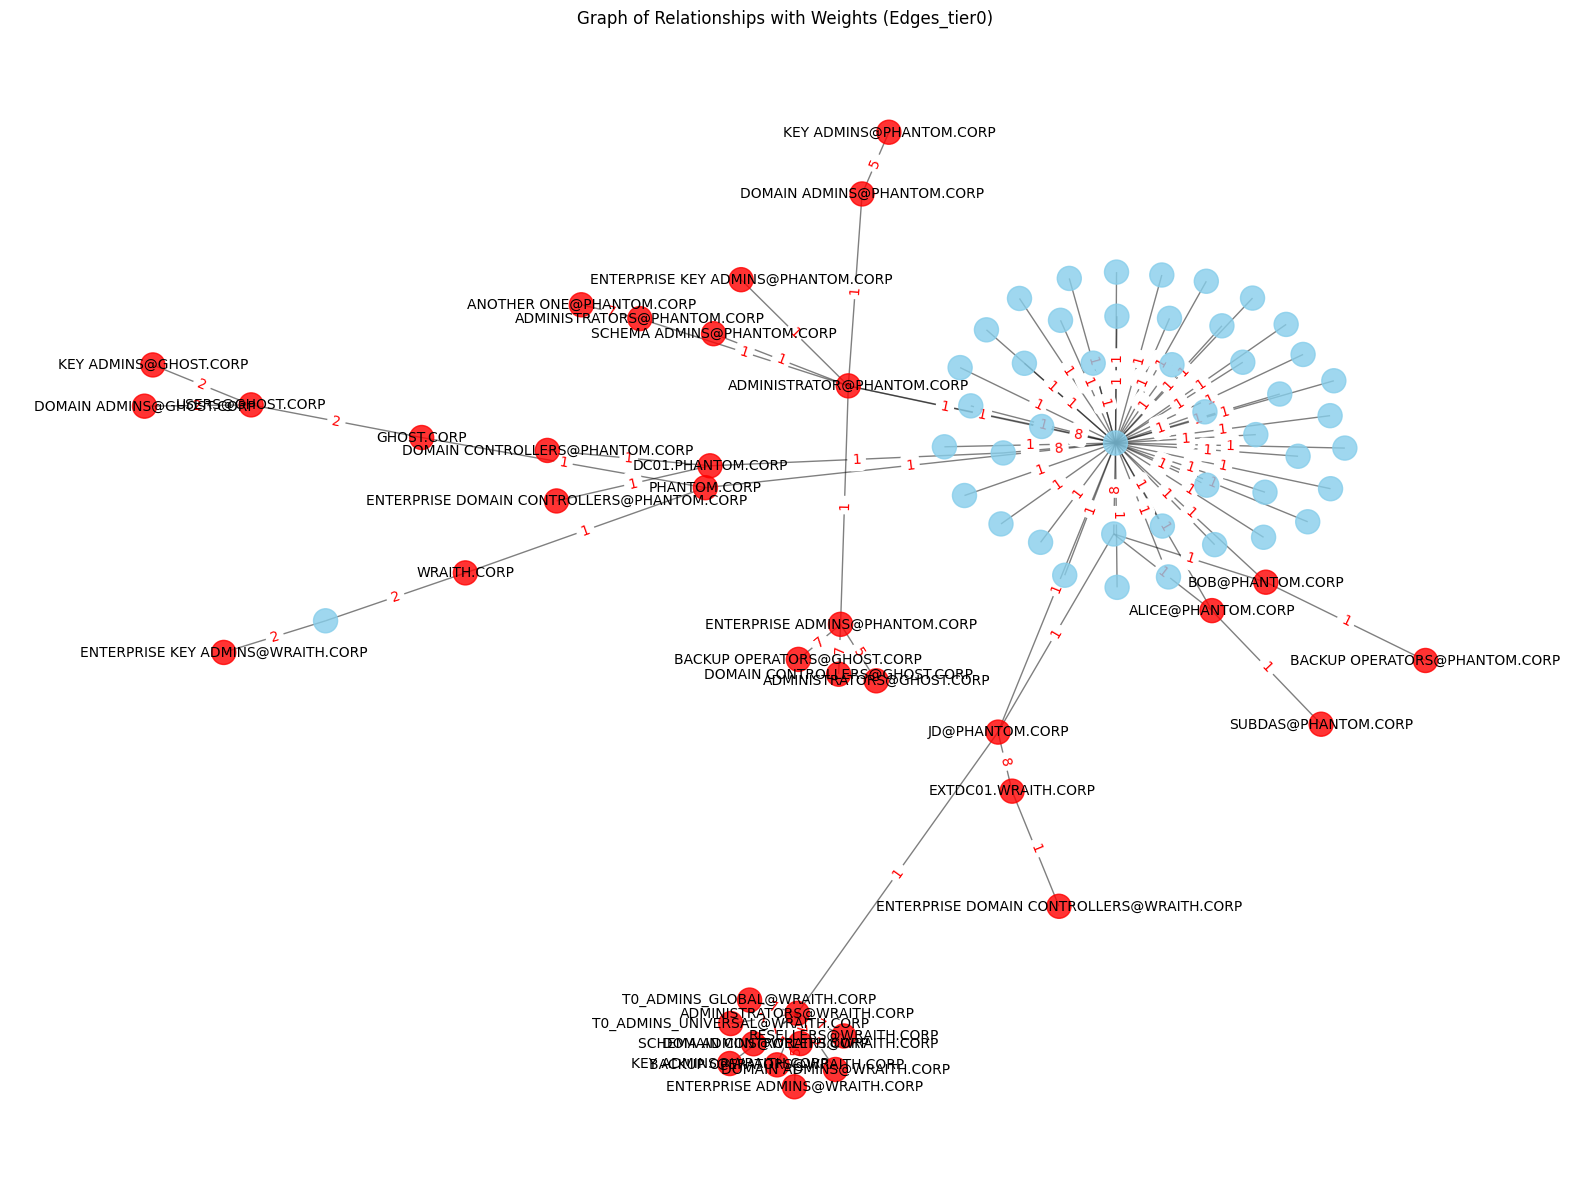

In [93]:
# prompt: using matplotlib.pyplot can you create the whole graph

import matplotlib.pyplot as plt
import networkx as nx

# Create a graph from the edges DataFrame
G = nx.from_pandas_edgelist(edges_tier0, 'source', 'target', edge_attr='weight')

# Add nodes that are not in the edges DataFrame but are in nodes_tier0
# This handles nodes that might be isolated in the edges list but exist in the node list
isolated_nodes = set(nodes_tier0['node_id']) - set(G.nodes())
G.add_nodes_from(isolated_nodes)

# Draw the graph
plt.figure(figsize=(20, 15))
pos = nx.spring_layout(G, seed=42)  # You can choose different layouts

# Draw nodes
# You can customize node appearance based on attributes if needed
node_colors = []
for node in G.nodes():
    if node in unique_targets_set:
        node_colors.append('red') # Color target nodes
    elif node in start_nodes_to_check:
         node_colors.append('green') # Color starting nodes
    elif node == 9999:
        node_colors.append('purple') # Color the 9999 node if it exists
    else:
        node_colors.append('skyblue') # Default color

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300, alpha=0.8)

# Draw edges with weights as labels
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.5)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

# Draw labels for nodes
# You might want to label important nodes or all nodes depending on graph size
node_labels = {}
for node in G.nodes():
    # Only label certain nodes to avoid clutter, e.g., starting nodes and target nodes
    if node in start_nodes_to_check or node in unique_targets_set or node == 9999:
         # Look up the label in nodes_tier0 if available
         node_info = nodes_tier0[nodes_tier0['node_id'] == node]
         if not node_info.empty:
              node_labels[node] = node_info['label'].iloc[0] # Use the 'label' from nodes_tier0
         elif node == 9999:
              node_labels[node] = 'Target 9999' # Label the special target node
         else:
             node_labels[node] = str(node) # Fallback to node ID

nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=10)

plt.title("Graph of Relationships with Weights (Edges_tier0)")
plt.axis('off') # Hide axes
plt.show()


In [94]:
# prompt: do you support yfiles graph, if not is there somthing similar

# Example using pyvis for interactive visualization (assuming you have G from networkx)
!pip install pyvis

from pyvis.network import Network

# Create a PyVis network
net = Network(height="750px", width="100%", bgcolor="#222222", font_color="white", notebook=True)

# Add nodes from your NetworkX graph G
for node, data in G.nodes(data=True):
    # You can customize node properties here based on your nodes_tier0 data
    node_label = str(node)
    color = 'skyblue' # Default color
    if node in unique_targets_set:
        color = 'red'
    elif node in start_nodes_to_check:
        color = 'green'
    elif node == 9999:
        color = 'purple'

    # Look up the label from nodes_tier0 if available for tooltip
    node_info = nodes_tier0[nodes_tier0['node_id'] == node]
    title = f"Node ID: {node}"
    if not node_info.empty:
        label_from_df = node_info['label'].iloc[0]
        title += f"<br>Label: {label_from_df}"
        # You might use the label from df for the node display if it's short enough
        # node_label = label_from_df
    elif node == 9999:
         title += "<br>Label: Target 9999"


    net.add_node(node, label=node_label, title=title, color=color, size=10) # Adjust size as needed

# Add edges from your NetworkX graph G
for source, target, data in G.edges(data=True):
    weight = data.get('weight', 1) # Get weight, default to 1 if not present
    # Add title for the edge to show weight on hover
    edge_title = f"Weight: {weight}"
    net.add_edge(source, target, weight=weight, title=edge_title)

# Customize visualization options (optional)
# net.set_options("""
# var options = {
#   "forceAtlas2Based": {
#     "gravitationalConstant": -50,
#     "centralGravity": 0.01,
#     "springConstant": 0.08,
#     "springLength": 100,
#     "damping": 0.4,
#     "avoidOverlap": 0
#   },
#   "physics": {
#     "enabled": true
#   }
# }
# """)


# Display the interactive graph in the notebook
net.show("interactive_graph.html")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.9 MB/s eta 0:00:00
interactive_graph.html


In [88]:
# Apply the weights based on the 'label' column to edges_tier0
def assign_weight(label):
    if label == "GenericAll":
        return 9
    elif label == "Owns":
        return 10
    elif label == "GenericWrite":
        return 2
    elif label == "AllExtendedRights":
        return 6
    elif label == "CanRDP":
        return 2
    elif label == "Contains":
        return 2
    elif label == "DCSync":
        return 8
    elif label == "WriteDacl":
        return 5
    elif label == "WriteOwner":
        return 7
    elif label == "AddKeyCredentialLink":
        return 6
    elif label == "AdminTo":
        return 8
    elif label == "MemberOf":
        return 1
    elif label == "CanPSRemote":
        return 2
    elif label == "ExecuteDCOM":
        return 2
    elif label == "GPLink":
        return 3
    elif label == "tier0":
        return 20
    else:
        return 1 # Default weight for other labels

edges_tier0['weight'] = edges_tier0['label'].apply(assign_weight)

# Display the updated edges_tier0 DataFrame with the 'weight' column
print("\nEdges_tier0 DataFrame with weight column:")
edges_tier0.head() # Display head to avoid printing the entire DataFrame


Edges_tier0 DataFrame with weight column:


,source,target,label,kind,lastSeen,weight
0,1199,1456,AdminTo,AdminTo,2025-05-21T13:35:52.180600782Z,8
1,1456,1461,AllowedToDelegate,AllowedToDelegate,2025-05-21T13:35:15.51961565Z,1
2,1461,1194,MemberOf,MemberOf,2025-05-21T13:35:15.51961565Z,1
3,1199,1463,AdminTo,AdminTo,2025-05-21T13:35:52.180600782Z,8
4,1463,975,HasSession,HasSession,2025-05-21T13:35:15.51961565Z,1


In [72]:
edges_tier0

,source,target,label,kind,lastSeen
0,1199,1456,AdminTo,AdminTo,2025-05-21T13:35:52.180600782Z
1,1456,1461,AllowedToDelegate,AllowedToDelegate,2025-05-21T13:35:15.51961565Z
2,1461,1194,MemberOf,MemberOf,2025-05-21T13:35:15.51961565Z
3,1199,1463,AdminTo,AdminTo,2025-05-21T13:35:52.180600782Z
4,1463,975,HasSession,HasSession,2025-05-21T13:35:15.51961565Z
5,975,1195,MemberOf,MemberOf,2025-05-21T13:35:15.600287567Z
6,975,1196,MemberOf,MemberOf,2025-05-21T13:35:15.600287567Z
7,975,1202,MemberOf,MemberOf,2025-05-21T13:35:15.600287567Z
8,1199,1455,AdminTo,AdminTo,2025-05-21T13:35:52.180600782Z
9,1455,980,HasSession,HasSession,2025-05-21T13:35:15.51961565Z


In [71]:
# prompt: find the shortest path from the pandas dataframe "edges_tier0"

import pandas as pd
def get_path_details(path, nodes_df):
    """
    Retrieves the label and kind for each node ID in a given path.

    Args:
        path (list): A list of node IDs representing the path.
        nodes_df (pd.DataFrame): DataFrame with 'node_id', 'label', and 'kind' columns.

    Returns:
        list: A list of dictionaries, where each dictionary contains
              the node_id, label, and kind for a node in the path.
    """
    path_details = []
    for node_id in path:
        node_info = nodes_df[nodes_df['node_id'] == node_id]
        if not node_info.empty:
            details = {
                'node_id': node_id,
                'label': node_info['label'].iloc[0],
                'kind': node_info['kind'].iloc[0]
            }
            path_details.append(details)
        else:
            # Handle cases where a node in the path might not be in nodes_df
            path_details.append({'node_id': node_id, 'label': 'Unknown', 'kind': 'Unknown'})
    return path_details

print(f"\nShortest paths from node {start_node} to tier0 target nodes (where the node is istier0=True) with details:")
if shortest_paths_to_tier0_targets:
    for target_node_id, distance in shortest_paths_to_tier0_targets.items():
        # Reconstruct the path
        path = []
        current = target_node_id
        while current is not None and current in path_predecessors:
            path.append(current)
            current = path_predecessors[current]
        # Add the start node if it's not in path_predecessors (which it won't be)
        if start_node not in path:
             path.append(start_node)
        path.reverse()

        # Get details for each node in the path
        path_details = get_path_details(path, nodes_all)

        print(f"  To node {target_node_id} ({nodes_all[nodes_all['node_id'] == target_node_id]['label'].iloc[0]}): Distance = {distance}")
        print("    Path:")
        for i, node_detail in enumerate(path_details):
            print(f"      Step {i}: Node ID: {node_detail['node_id']}, Label: {node_detail['label']}, Kind: {node_detail['kind']}")
else:
    print(f"  No reachable tier0 target nodes (where istier0=True) found from node {start_node}.")



Shortest paths from node 1021 to tier0 target nodes (where the node is istier0=True) with details:
  No reachable tier0 target nodes (where istier0=True) found from node 1021.


In [59]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd # Import pandas as it's used to create the graph

# Create a graph from the edges
# Assuming edges_all DataFrame is available from previous steps
G = nx.from_pandas_edgelist(edges_tier0, 'source', 'target', create_using=nx.DiGraph())

# using dijkstra_path_length show me the longest path in the graph

def find_longest_path_dijkstra(graph):
    longest_path = []
    longest_length = 0

    # Iterate through all possible start and end nodes
    for start_node in graph.nodes():
        for end_node in graph.nodes():
            if start_node != end_node:
                try:
                    # Calculate the shortest path length using Dijkstra's algorithm
                    # For the 'longest path' we need to consider that edge weights
                    # could be interpreted differently. If no weights are defined,
                    # dijkstra_path_length finds the shortest path in terms of number of edges.
                    # To find the *longest* simple path in an unweighted graph,
                    # Dijkstra's shortest path algorithm is not the direct solution.
                    # Finding the longest simple path is generally an NP-hard problem.

                    # However, based on the request asking to use dijkstra_path_length,
                    # we can interpret this as finding the longest *shortest* path among
                    # all pairs of nodes. This doesn't find the longest simple path
                    # but the path with the maximum minimum distance between any two nodes.
                    # If the edges had weights, dijkstra_path_length would use those weights.
                    # Since there are no weights in your graph creation, it assumes a weight of 1 for each edge.

                    # Let's proceed with finding the longest shortest path between all pairs
                    # as per the function requested.
                    length = nx.dijkstra_path_length(graph, start_node, end_node)

                    # We also need the actual path to identify the nodes
                    path = nx.dijkstra_path(graph, start_node, end_node)

                    if length > longest_length:
                        longest_length = length
                        longest_path = path

                except nx.NetworkXNoPath:
                    # No path exists between start and end nodes
                    pass

    return longest_path, longest_length

# Find the longest shortest path using the function
longest_path, longest_length = find_longest_path_dijkstra(G)
longest_path_int = [int(node) for node in longest_path]
print(f"The longest shortest path (in terms of number of edges) is: {longest_path}")
print(f"The length of this path is: {longest_length}")

# Note: This code finds the path with the maximum number of edges among all
# shortest paths between any two nodes using Dijkstra's algorithm on the unweighted graph.
# This is NOT the longest simple path in the graph, which is a different and harder problem.

The longest shortest path (in terms of number of edges) is: [1463, 975, 1199, 1478, 1479, 209, 1275]
The length of this path is: 6


In [51]:
 #prompt: covert longest_path to int

longest_path_int = [int(node) for node in longest_path]

print(f"The longest shortest path as integers is: {longest_path_int}")

The longest shortest path as integers is: [1463, 975, 1199, 1478, 1479, 209, 1275]


In [56]:
# iterate through longest path and find the corresponding node in nodes_all ,
# similar to:  node_6071 = nodes_all[nodes_all['node_id'] == 6071]

# Iterate through the node IDs in the longest path
for node_id in longest_path_int:
  # Filter the nodes_all DataFrame to find the row corresponding to the current node_id
  #corresponding_node = nodes_all[nodes_all['original_key'] == node_id]
  corresponding_node= nodes_tier0[nodes_tier0['node_id'] == node_id]
  # You can then access and print information about the corresponding node
  if not corresponding_node.empty:
    print(f"Node ID: {node_id}")
    print(corresponding_node)
    print("-" * 20)
  else:
    print(f"Node ID: {node_id} not found in nodes_all")
    print("-" * 20)

Node ID: 1463
    node_id                        label      kind  \
38     1463  DF-WIN10-DEV01.PHANTOM.CORP  Computer   

                                              OID istier0 isOwned  \
38  S-1-5-21-2697957641-2271029196-387917394-2124   False   False   

                    lastSeen  
38  2025-05-21T13:35:35.832Z  
--------------------
Node ID: 975
   node_id                       label  kind  \
2      975  ADMINISTRATOR@PHANTOM.CORP  User   

                                            OID istier0 isOwned  \
2  S-1-5-21-2697957641-2271029196-387917394-500    True   False   

                   lastSeen  
2  2025-05-21T13:35:36.865Z  
--------------------
Node ID: 1199
   node_id                      label   kind  \
9     1199  DOMAIN USERS@PHANTOM.CORP  Group   

                                            OID istier0 isOwned  \
9  S-1-5-21-2697957641-2271029196-387917394-513   False   False   

                   lastSeen  
9  2025-05-21T13:35:36.081Z  
--------------------
No

# Longest Path

In [ ]:
      # when printing out in the statment "print(f"Node ID: {node_id}")" i would just like to see the node_id nad label, not the full record

# Iterate through the node IDs in the longest path
for node_id in longest_path_int:
  # Filter the nodes_all DataFrame to find the row corresponding to the current node_id
  corresponding_node= nodes_all[nodes_all['node_id'] == node_id]
  # You can then access and print information about the corresponding node
  if not corresponding_node.empty:
    print(f"Node ID: {node_id}, Label: {corresponding_node['label'].iloc[0]}")
    print("-" * 20)
  else:
    print(f"Node ID: {node_id} not found in nodes_all")
    print("-" * 20)

Node ID: 7630, Label: ROSEANN_FISCHER@MYLAB.LOCAL
--------------------
Node ID: 5188, Label: BR-EDUFER191-ADMINGROUP1@MYLAB.LOCAL
--------------------
Node ID: 7583, Label: CLAUDE_GIBSON@MYLAB.LOCAL
--------------------
Node ID: 5177, Label: DE-DAS-DISTLIST1@MYLAB.LOCAL
--------------------
Node ID: 7204, Label: DORTHY_ROWE@MYLAB.LOCAL
--------------------
Node ID: 9999, Label: tier0@MYLAB.LOCAL
--------------------


# Graph Visualization

Drawing the entire graph:


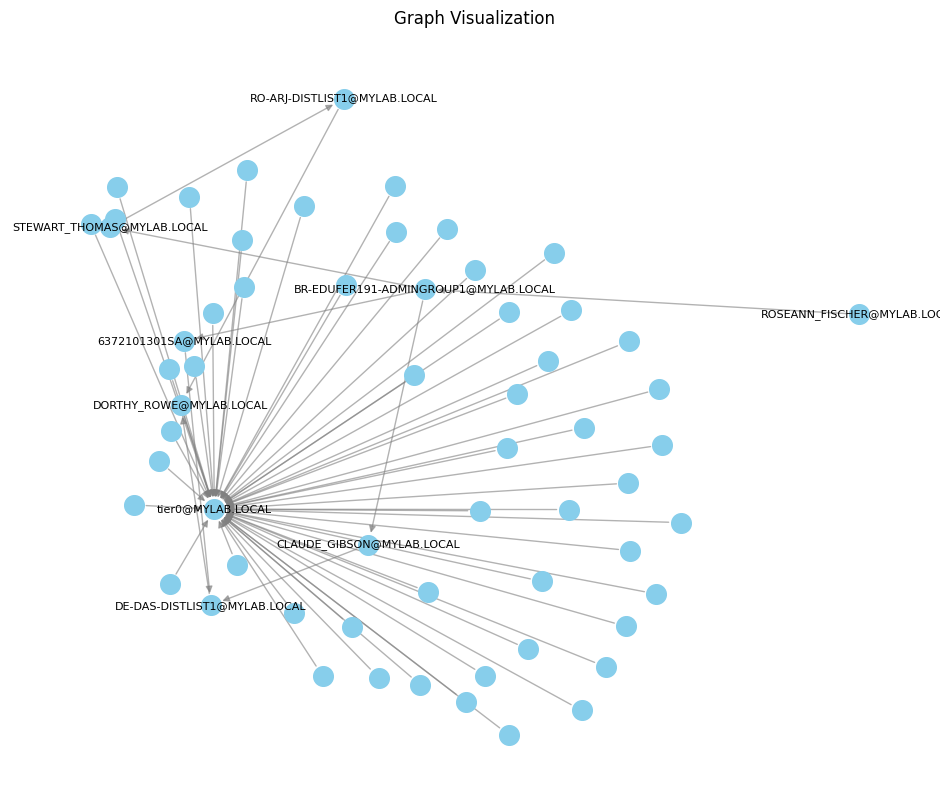


Drawing the graph with the longest shortest path highlighted:


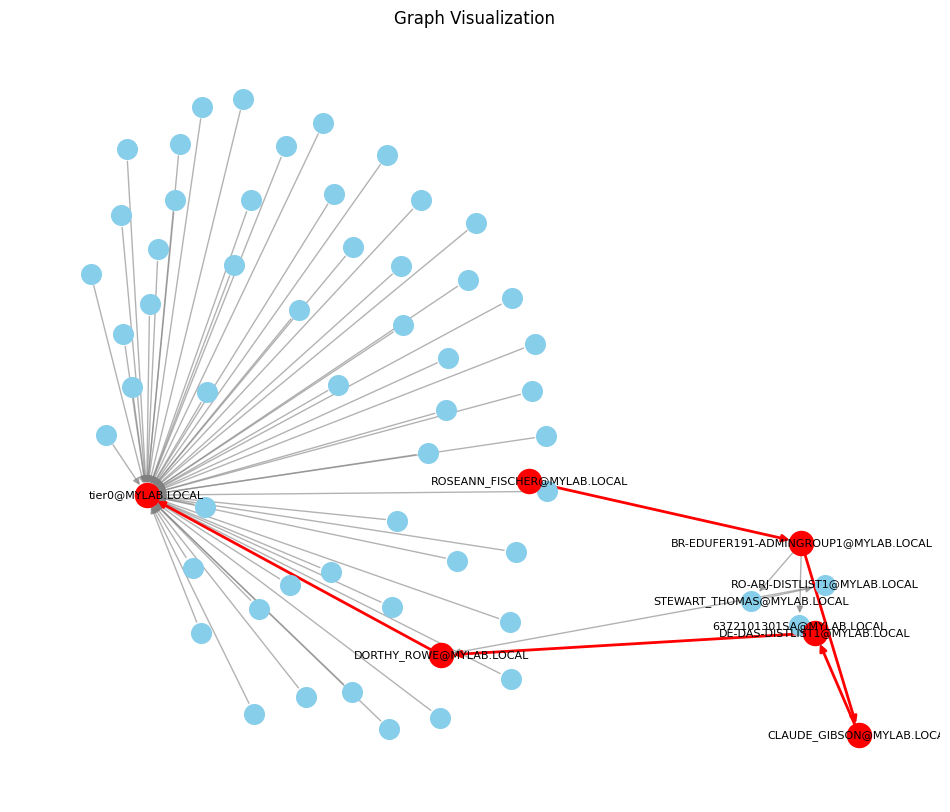


Drawing the graph with the path from 7583 to 9999 highlighted:


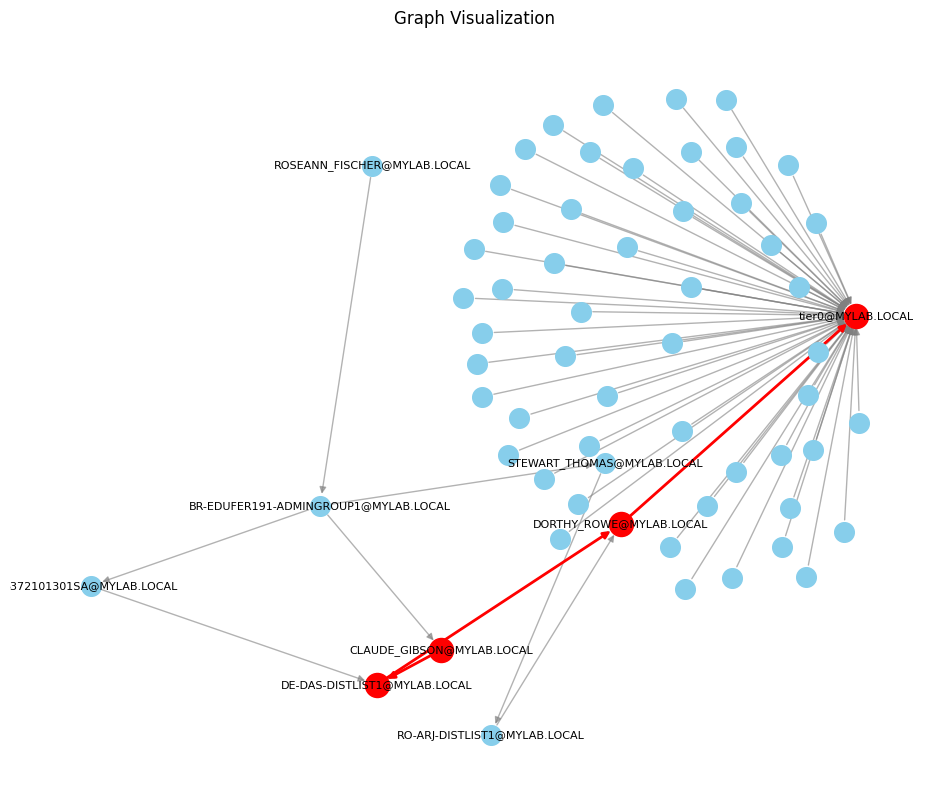

In [ ]:
# can you show this in a graph

import matplotlib.pyplot as plt
# Function to draw the graph
def draw_graph(graph, path_nodes=None, path_edges=None, node_labels=None):
    plt.figure(figsize=(12, 10)) # Adjust figure size as needed

    pos = nx.spring_layout(graph, k=0.5) # Use spring layout for better visualization of nodes and edges, k adjusts the spacing

    # Draw all nodes
    nx.draw_networkx_nodes(graph, pos, node_size=200, node_color='skyblue')

    # Draw all edges
    nx.draw_networkx_edges(graph, pos, edge_color='gray', alpha=0.6)

    # Highlight nodes in the path if provided
    if path_nodes:
        nx.draw_networkx_nodes(graph, pos, nodelist=path_nodes, node_color='red', node_size=300)

    # Highlight edges in the path if provided
    if path_edges:
        nx.draw_networkx_edges(graph, pos, edgelist=path_edges, edge_color='red', width=2)

    # Draw node labels if provided
    if node_labels:
        nx.draw_networkx_labels(graph, pos, labels=node_labels, font_size=8)
    else:
        # Draw default node labels (node IDs)
        nx.draw_networkx_labels(graph, pos, font_size=8)


    plt.title("Graph Visualization")
    plt.axis('off') # Hide axes
    plt.show()

# --- Visualize the graph ---

# Create node labels from the 'label' column in nodes_all
# Make sure node_id is the index or a column you can map to the graph nodes
node_labels = nodes_all.set_index('node_id')['label'].to_dict()

# Draw the entire graph with labels
print("Drawing the entire graph:")
draw_graph(G, node_labels=node_labels)


# --- Visualize the longest shortest path ---

# Get the edges in the longest shortest path
path_edges = [(longest_path_int[i], longest_path_int[i+1]) for i in range(len(longest_path_int)-1)]

# Draw the graph highlighting the longest shortest path and its nodes
print("\nDrawing the graph with the longest shortest path highlighted:")
draw_graph(G, path_nodes=longest_path_int, path_edges=path_edges, node_labels=node_labels)


# --- Visualize the found path from random node to target (if found) ---

if found_path:
    found_path_int = [int(node) for node in found_path]
    found_path_edges = [(found_path_int[i], found_path_int[i+1]) for i in range(len(found_path_int)-1)]
    print(f"\nDrawing the graph with the path from {random_start_node} to {target_node} highlighted:")
    draw_graph(G, path_nodes=found_path_int, path_edges=found_path_edges, node_labels=node_labels)
else:
    print("\nNo path found to highlight for the random node to target.")

Drawing the entire graph:


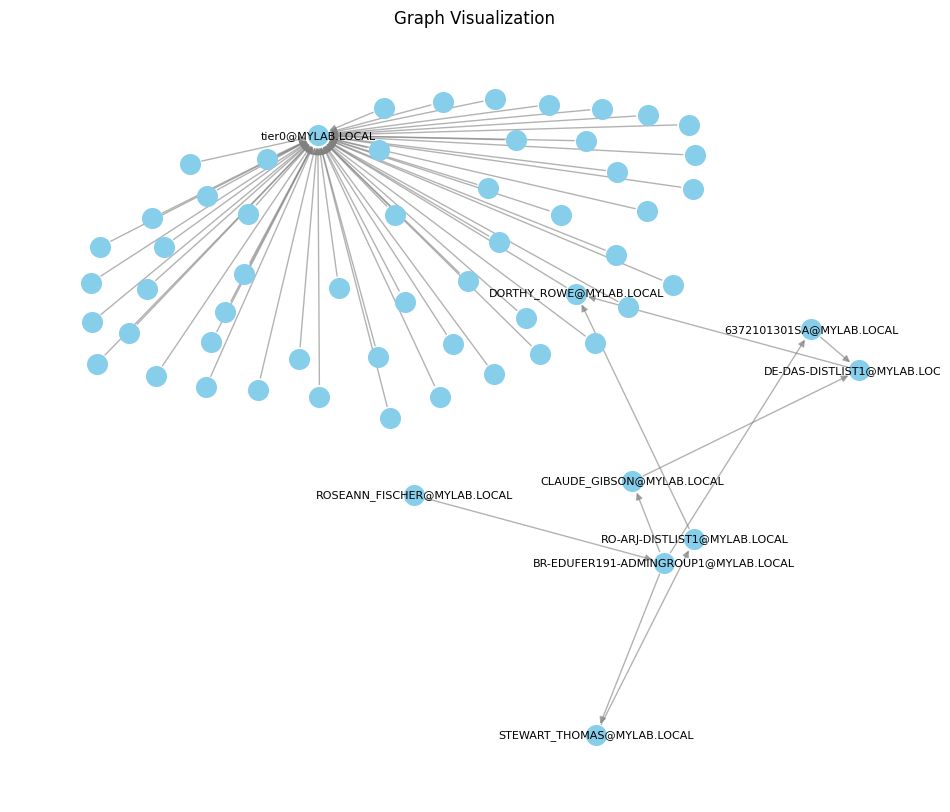


Drawing the graph with the longest shortest path highlighted:


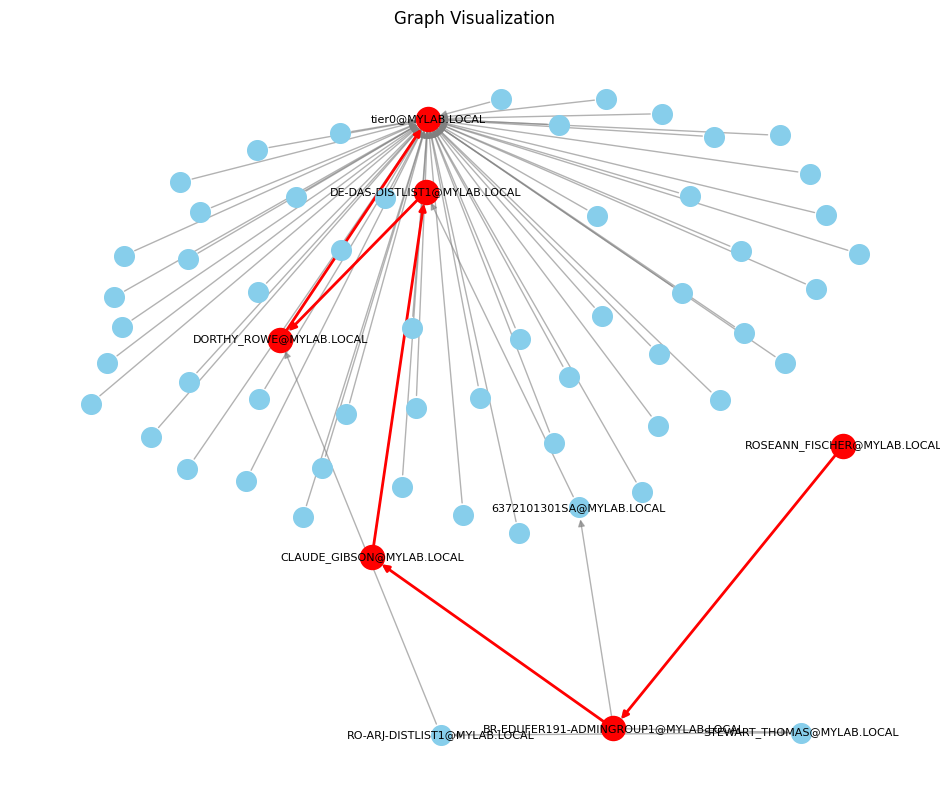


Path found from 8364 to 9999: [8364, 9999]

Drawing the graph with the path from 8364 to 9999 highlighted:


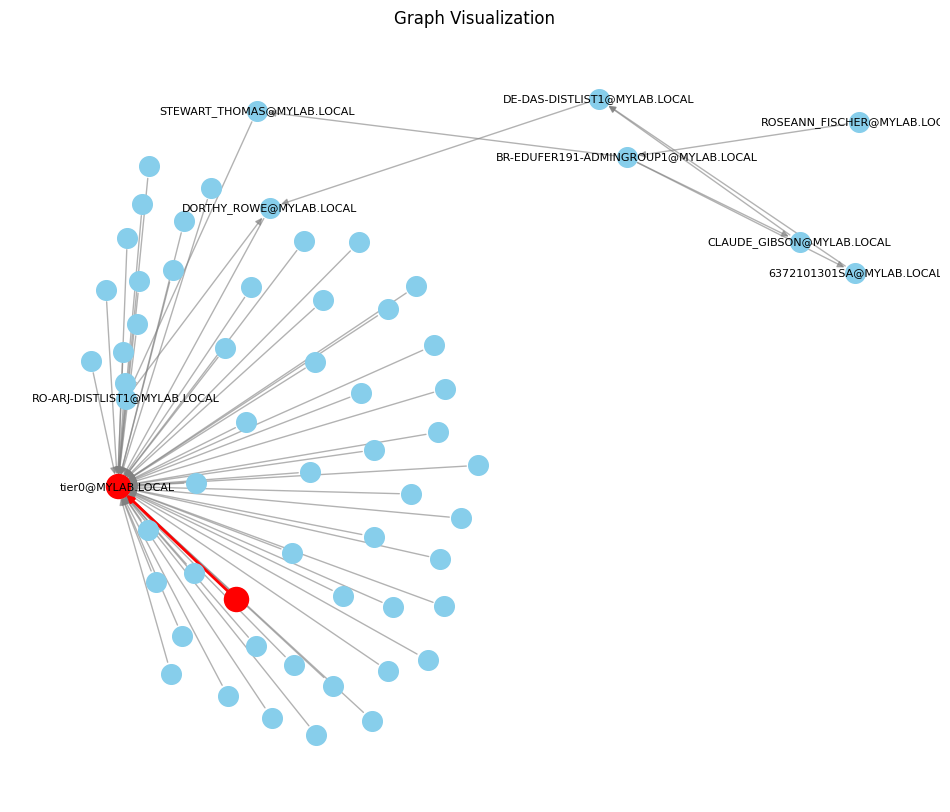

In [ ]:
# can you show this in a graph

import matplotlib.pyplot as plt
import networkx as nx # Ensure networkx is imported
import random # Import random for selecting a random node

# Function to draw the graph
def draw_graph(graph, path_nodes=None, path_edges=None, node_labels=None):
    plt.figure(figsize=(12, 10)) # Adjust figure size as needed

    pos = nx.spring_layout(graph, k=0.5) # Use spring layout for better visualization of nodes and edges, k adjusts the spacing

    # Draw all nodes
    nx.draw_networkx_nodes(graph, pos, node_size=200, node_color='skyblue')

    # Draw all edges
    nx.draw_networkx_edges(graph, pos, edge_color='gray', alpha=0.6)

    # Highlight nodes in the path if provided
    if path_nodes:
        nx.draw_networkx_nodes(graph, pos, nodelist=path_nodes, node_color='red', node_size=300)

    # Highlight edges in the path if provided
    if path_edges:
        nx.draw_networkx_edges(graph, pos, edgelist=path_edges, edge_color='red', width=2)

    # Draw node labels if provided
    if node_labels:
        nx.draw_networkx_labels(graph, pos, labels=node_labels, font_size=8)
    else:
        # Draw default node labels (node IDs)
        nx.draw_networkx_labels(graph, pos, font_size=8)


    plt.title("Graph Visualization")
    plt.axis('off') # Hide axes
    plt.show()

# --- Visualize the graph ---

# Create node labels from the 'label' column in nodes_all
# Make sure node_id is the index or a column you can map to the graph nodes
node_labels = nodes_all.set_index('node_id')['label'].to_dict()

# Draw the entire graph with labels
print("Drawing the entire graph:")
draw_graph(G, node_labels=node_labels)


# --- Visualize the longest shortest path ---

# Get the edges in the longest shortest path
path_edges = [(longest_path_int[i], longest_path_int[i+1]) for i in range(len(longest_path_int)-1)]

# Draw the graph highlighting the longest shortest path and its nodes
print("\nDrawing the graph with the longest shortest path highlighted:")
draw_graph(G, path_nodes=longest_path_int, path_edges=path_edges, node_labels=node_labels)


# --- Visualize the found path from random node to target (if found) ---

# Define a target node (you can change this to any node ID you want)
# Make sure the target_node exists in the graph's nodes
target_node = 9999  # Assuming 9999 is a valid node in your graph

# Select a random starting node from the graph's nodes
# Ensure the random node is not the target node
graph_nodes = list(G.nodes())
random_start_node = random.choice(graph_nodes)
while random_start_node == target_node:
    random_start_node = random.choice(graph_nodes)


# Find a path from the random start node to the target node using Dijkstra's algorithm
# This will find the shortest path in terms of number of edges since no weights are used in graph creation
try:
    found_path = nx.dijkstra_path(G, source=random_start_node, target=target_node)
    print(f"\nPath found from {random_start_node} to {target_node}: {found_path}")
except nx.NetworkXNoPath:
    found_path = None
    print(f"\nNo path found from {random_start_node} to {target_node}")


if found_path:
    found_path_int = [int(node) for node in found_path]
    found_path_edges = [(found_path_int[i], found_path_int[i+1]) for i in range(len(found_path_int)-1)]
    print(f"\nDrawing the graph with the path from {random_start_node} to {target_node} highlighted:")
    draw_graph(G, path_nodes=found_path_int, path_edges=found_path_edges, node_labels=node_labels)
else:
    print("\nNo path found to highlight for the random node to target.")